# Proyek Analisis Data: Brazilian E-Commerce
**Nama:** Raihanah Nurkhalishah
**Email:** raihanahnurkhalishah@gmail.com

## Pertanyaan Bisnis
1. Bagaimana tren total revenue bulanan Olist selama periode 2016–2018, dan pada bulan apa revenue tertinggi terjadi?

2. Bagaimana segmentasi pelanggan Olist berdasarkan metode RFM (Recency, Frequency, Monetary) dan kategori pelanggan mana yang paling dominan selama periode 2016–2018?

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load semua dataset
orders = pd.read_csv('data/orders_dataset.csv')
order_items = pd.read_csv('data/order_items_dataset.csv')
order_payments = pd.read_csv('data/order_payments_dataset.csv')
customers = pd.read_csv('data/customers_dataset.csv')
products = pd.read_csv('data/products_dataset.csv')
sellers = pd.read_csv('data/sellers_dataset.csv')
geolocation = pd.read_csv('data/geolocation_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')
order_reviews = pd.read_csv('data/order_reviews_dataset.csv')

print("Semua data berhasil dimuat!")

Semua data berhasil dimuat!


## Gathering Data
Pada tahap ini, kita memuat semua dataset yang dibutuhkan dan melihat sekilas isi serta struktur datanya.

In [65]:
# Cek shape semua dataframe
print("=== SHAPE SETIAP DATASET ===")
print(f"orders         : {orders.shape}")
print(f"order_items    : {order_items.shape}")
print(f"order_payments : {order_payments.shape}")
print(f"customers      : {customers.shape}")
print(f"products       : {products.shape}")
print(f"sellers        : {sellers.shape}")
print(f"geolocation    : {geolocation.shape}")
print(f"category_trans : {category_translation.shape}")
print(f"order_reviews  : {order_reviews.shape}")

=== SHAPE SETIAP DATASET ===
orders         : (99441, 8)
order_items    : (112650, 7)
order_payments : (103886, 5)
customers      : (99441, 5)
products       : (32951, 9)
sellers        : (3095, 4)
geolocation    : (1000163, 5)
category_trans : (71, 2)
order_reviews  : (99224, 7)


In [66]:
# Preview tiap dataset
print("=== ORDERS ===")
display(orders.head(3))

print("=== ORDER ITEMS ===")
display(order_items.head(3))

print("=== ORDER PAYMENTS ===")
display(order_payments.head(3))

print("=== CUSTOMERS ===")
display(customers.head(3))

print("=== PRODUCTS ===")
display(products.head(3))

=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


=== ORDER ITEMS ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


=== ORDER PAYMENTS ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


=== CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


=== PRODUCTS ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


## Assessing Data
Pada tahap ini, kita menilai kualitas data dengan mengidentifikasi masalah seperti missing values, duplikasi, dan tipe data yang tidak sesuai.

In [67]:
# Cek missing values semua dataset
datasets = {
    'orders': orders,
    'order_items': order_items,
    'order_payments': order_payments,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation,
    'order_reviews': order_reviews
}

print("=== MISSING VALUES PER DATASET ===")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        print(missing)
    else:
        print(f"\n{name}: tidak ada missing value ✓")

=== MISSING VALUES PER DATASET ===

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items: tidak ada missing value ✓

order_payments: tidak ada missing value ✓

customers: tidak ada missing value ✓

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

sellers: tidak ada missing value ✓

geolocation: tidak ada missing value ✓

category_translation: tidak ada missing value ✓

order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [68]:
# Cek duplikasi
print("=== DUPLIKASI PER DATASET ===")
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f"{name}: {dup} duplikat")

=== DUPLIKASI PER DATASET ===
orders: 0 duplikat
order_items: 0 duplikat
order_payments: 0 duplikat
customers: 0 duplikat
products: 0 duplikat
sellers: 0 duplikat
geolocation: 261831 duplikat
category_translation: 0 duplikat
order_reviews: 0 duplikat


In [69]:
# Cek tipe data orders (dataset utama)
print("=== TIPE DATA ORDERS ===")
print(orders.dtypes)

print("\n=== TIPE DATA ORDER ITEMS ===")
print(order_items.dtypes)

print("\n=== TIPE DATA ORDER PAYMENTS ===")
print(order_payments.dtypes)

print("=== TIPE DATA CUSTOMERS ===")
print(customers.dtypes)

print("\n=== TIPE DATA PRODUCTS ===")
print(products.dtypes)

print("\n=== TIPE DATA SELLERS ===")
print(sellers.dtypes)

print("\n=== TIPE DATA GEOLOCATION ===")
print(geolocation.dtypes)

print("\n=== TIPE DATA CATEGORY TRANSLATION ===")
print(category_translation.dtypes)

print("\n=== TIPE DATA ORDER REVIEWS ===")
print(order_reviews.dtypes)

=== TIPE DATA ORDERS ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== TIPE DATA ORDER ITEMS ===
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

=== TIPE DATA ORDER PAYMENTS ===
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
=== TIPE DATA CUSTOMERS ===
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
cus

## Cleaning Data
Berdasarkan hasil assessing, ditemukan beberapa masalah berikut:
1. Missing values pada kolom tanggal di `orders`
2. Missing values pada kolom produk di `products`
3. Duplikasi pada `geolocation` sebanyak 261.831 baris
4. Tipe data kolom tanggal masih `object`, perlu diubah ke `datetime`

In [70]:
# Konversi kolom tanggal ke datetime
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col])

# Konversi di order_items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Konversi di order_reviews
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

print("\nTipe data orders setelah konversi:")
print(orders.dtypes)


Tipe data orders setelah konversi:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [71]:
# Orders: missing values DIBIARKAN
# Alasan: kolom delivery date kosong karena order belum/tidak sampai tahap pengiriman
# Solusi: nanti difilter hanya ambil order status 'delivered' saat analisis

print("=== ORDERS - Missing values dibiarkan ===")
print(f"Total baris orders: {orders.shape[0]}")
print(f"Baris dengan status 'delivered': {(orders['order_status'] == 'delivered').sum()}")


=== ORDERS - Missing values dibiarkan ===
Total baris orders: 99441
Baris dengan status 'delivered': 96478


In [72]:
# Products: missing values DIHAPUS
# Alasan: data produk tidak lengkap tidak berguna untuk analisis kategori

print(f"Sebelum: {products.shape}")
products = products.dropna()
print(f"Sesudah: {products.shape}")

print("\nMissing values products setelah cleaning:")
print(products.isnull().sum())

Sebelum: (32951, 9)
Sesudah: (32340, 9)

Missing values products setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [73]:
# Order reviews: kolom komentar DIBIARKAN
# Alasan: kolom review_comment_title dan review_comment_message memang opsional diisi oleh customer, bukan data rusak

print("=== ORDER REVIEWS - Kolom komentar dibiarkan ===")
print(f"Total baris order_reviews: {order_reviews.shape[0]}")
print(f"Missing review_comment_title: {order_reviews['review_comment_title'].isnull().sum()}")
print(f"Missing review_comment_message: {order_reviews['review_comment_message'].isnull().sum()}")

=== ORDER REVIEWS - Kolom komentar dibiarkan ===
Total baris order_reviews: 99224
Missing review_comment_title: 87656
Missing review_comment_message: 58247


In [74]:
# Hapus duplikasi geolocation
print(f"Sebelum: {geolocation.shape}")
geolocation = geolocation.drop_duplicates()
print(f"Sesudah: {geolocation.shape}")

Sebelum: (1000163, 5)
Sesudah: (738332, 5)


In [75]:
print("=== VERIFIKASI AKHIR SETELAH CLEANING ===")

print("\n1. Tipe data orders (harus datetime):")
print(orders[['order_purchase_timestamp', 'order_approved_at']].dtypes)

print("\n2. Missing values products :")
print(products.isnull().sum().sum(), "missing values tersisa")

print("\n3. Duplikasi geolocation :")
print(geolocation.duplicated().sum(), "duplikat tersisa")

print("\n4. Shape akhir semua dataset:")
print(f"orders         : {orders.shape}")
print(f"order_items    : {order_items.shape}")
print(f"order_payments : {order_payments.shape}")
print(f"customers      : {customers.shape}")
print(f"products       : {products.shape}")
print(f"geolocation    : {geolocation.shape}")

=== VERIFIKASI AKHIR SETELAH CLEANING ===

1. Tipe data orders (harus datetime):
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object

2. Missing values products :
0 missing values tersisa

3. Duplikasi geolocation :
0 duplikat tersisa

4. Shape akhir semua dataset:
orders         : (99441, 8)
order_items    : (112650, 7)
order_payments : (103886, 5)
customers      : (99441, 5)
products       : (32340, 9)
geolocation    : (738332, 5)


## Exploratory Data Analysis (EDA)

Pada tahap ini, kita mengeksplorasi data untuk menjawab 2 pertanyaan bisnis:
1. Tren total revenue bulanan Olist selama periode 2016–2018
2. Segmentasi pelanggan berdasarkan RFM Analysis

In [76]:
# Merge orders + order_payments untuk mendapatkan revenue
order_revenue = orders.merge(order_payments, on='order_id', how='inner')

# Filter hanya order yang delivered
order_revenue = order_revenue[order_revenue['order_status'] == 'delivered']

# Tambah kolom year_month untuk grouping bulanan
order_revenue['year_month'] = order_revenue['order_purchase_timestamp'].dt.to_period('M')

print(f"Total order delivered: {order_revenue.shape[0]}")
print(order_revenue[['order_id', 'order_purchase_timestamp', 'year_month', 'payment_value']].head())

Total order delivered: 100756
                           order_id order_purchase_timestamp year_month  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33    2017-10   
1  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33    2017-10   
2  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33    2017-10   
3  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37    2018-07   
4  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49    2018-08   

   payment_value  
0          18.12  
1           2.00  
2          18.59  
3         141.46  
4         179.12  


In [77]:
# Hitung total revenue per bulan
monthly_revenue = order_revenue.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['year_month', 'total_revenue']
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

print("=== REVENUE BULANAN ===")
print(monthly_revenue)
print(f"\nBulan dengan revenue tertinggi:")
print(monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax()])

=== REVENUE BULANAN ===
   year_month  total_revenue
0     2016-10       46566.71
1     2016-12          19.62
2     2017-01      127545.67
3     2017-02      271298.65
4     2017-03      414369.39
5     2017-04      390952.18
6     2017-05      567066.73
7     2017-06      490225.60
8     2017-07      566403.93
9     2017-08      646000.61
10    2017-09      701169.99
11    2017-10      751140.27
12    2017-11     1153528.05
13    2017-12      843199.17
14    2018-01     1078606.86
15    2018-02      966510.88
16    2018-03     1120678.00
17    2018-04     1132933.95
18    2018-05     1128836.69
19    2018-06     1012090.68
20    2018-07     1027903.86
21    2018-08      985414.28

Bulan dengan revenue tertinggi:
year_month          2017-11
total_revenue    1153528.05
Name: 12, dtype: object


In [78]:
# Hitung jumlah order per bulan
monthly_orders = order_revenue.groupby('year_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['year_month', 'total_orders']
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

print("=== ORDER BULANAN ===")
print(monthly_orders)

=== ORDER BULANAN ===
   year_month  total_orders
0     2016-10           265
1     2016-12             1
2     2017-01           750
3     2017-02          1653
4     2017-03          2546
5     2017-04          2303
6     2017-05          3546
7     2017-06          3135
8     2017-07          3872
9     2017-08          4193
10    2017-09          4150
11    2017-10          4478
12    2017-11          7289
13    2017-12          5513
14    2018-01          7069
15    2018-02          6555
16    2018-03          7003
17    2018-04          6798
18    2018-05          6749
19    2018-06          6099
20    2018-07          6159
21    2018-08          6351


In [79]:
# Tentukan tanggal referensi (tanggal terakhir transaksi + 1 hari)
reference_date = order_revenue['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi RFM: {reference_date}")

# Merge dengan customers
rfm_df = order_revenue.merge(customers, on='customer_id', how='inner')

# Hitung RFM per customer
rfm = rfm_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("\n=== RFM DATAFRAME ===")
print(rfm.head())
print(f"\nShape: {rfm.shape}")
print(f"\nStatistik RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

Tanggal referensi RFM: 2018-08-30 15:00:37

=== RFM DATAFRAME ===
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

Shape: (93357, 4)

Statistik RFM:
            Recency     Frequency      Monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


In [80]:
# Buat skor RFM menggunakan quintile (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

# Gabung jadi RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("=== RFM SCORE ===")
print(rfm.head(10))

=== RFM SCORE ===
                 customer_unique_id  Recency  Frequency  Monetary R_Score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89       2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98       4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38       4   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18       3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12       1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76       4   

  F_Score M_Score RFM_Score  
0       1       4       414  
1       1       1       411  
2       1       2       112  
3       1     

In [81]:
# Segmentasi berdasarkan R dan F score
def rfm_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print("=== DISTRIBUSI SEGMEN ===")
print(rfm['Segment'].value_counts())

=== DISTRIBUSI SEGMEN ===
Segment
At Risk                22229
Loyal Customers        18824
Lost Customers         14986
New Customers          14984
Champions              14961
Potential Loyalists     7373
Name: count, dtype: int64


In [82]:
# Define Color Palette
COLOR_PRIMARY = '#DB1A1A'      # Merah bold - warna utama
COLOR_SECONDARY = '#FF7070'    # Merah medium
COLOR_PASTEL = '#FFA6A6'       # Merah pastel
COLOR_CREAM = '#FFF6F6'        # Putih kemerahan - background card
COLOR_TEAL = '#8CC7C4'         # Teal - kontras
COLOR_TEAL_DARK = '#2C687B'    # Teal gelap
COLOR_ACCENT = '#FFEDC7'       # Krem pastel - aksen

# Untuk segmen RFM
SEGMENT_COLORS = {
    'Champions': COLOR_PRIMARY,
    'Loyal Customers': COLOR_SECONDARY,
    'New Customers': COLOR_PASTEL,
    'At Risk': COLOR_TEAL,
    'Lost Customers': COLOR_TEAL_DARK,
    'Potential Loyalists': COLOR_ACCENT
}


## Visualization & Explanatory Analysis

Membuat visualisasi untuk menjawab kedua pertanyaan bisnis.

### Pertanyaan Bisnis 1: Tren Revenue Bulanan 2016-2018

Grafik Tren Revenue Bulanan

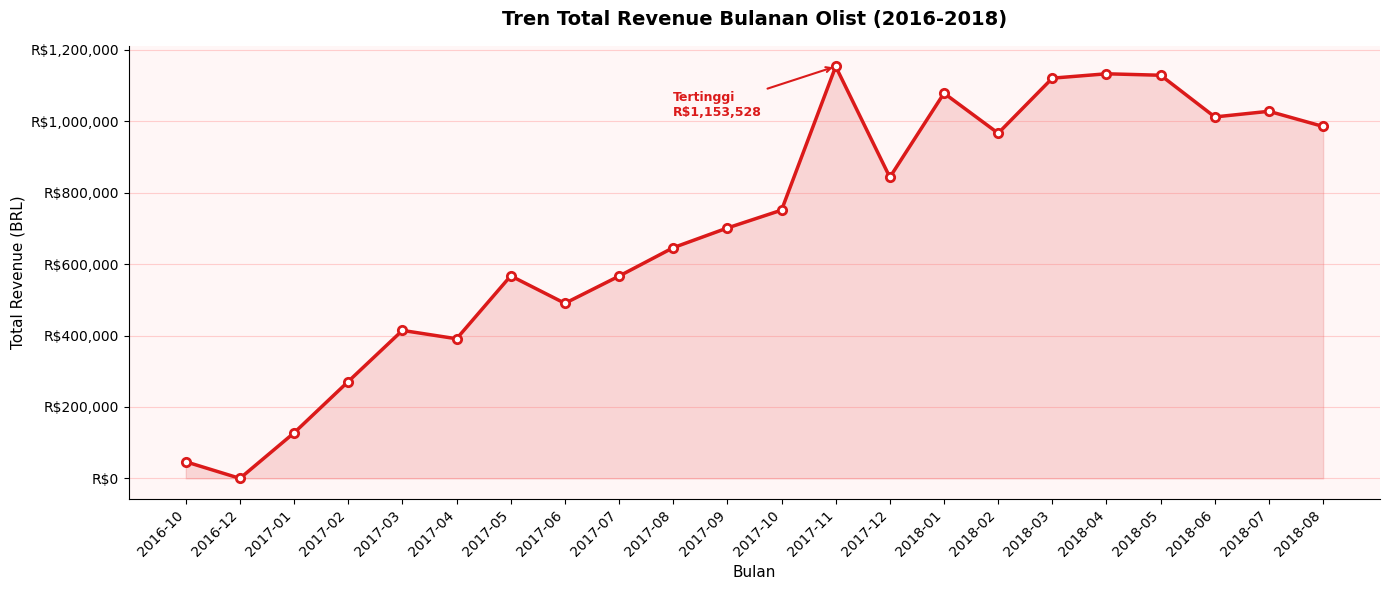

In [83]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(COLOR_CREAM)

ax.plot(range(len(monthly_revenue)),
        monthly_revenue['total_revenue'],
        marker='o', linewidth=2.5,
        color=COLOR_PRIMARY,
        markerfacecolor='white',
        markeredgecolor=COLOR_PRIMARY,
        markeredgewidth=2)

ax.fill_between(range(len(monthly_revenue)),
                monthly_revenue['total_revenue'],
                alpha=0.15, color=COLOR_PRIMARY)

# Tandai bulan tertinggi
max_idx = monthly_revenue['total_revenue'].idxmax()
ax.annotate(f"Tertinggi\nR${monthly_revenue['total_revenue'][max_idx]:,.0f}",
            xy=(max_idx, monthly_revenue['total_revenue'][max_idx]),
            xytext=(max_idx-3, monthly_revenue['total_revenue'][max_idx]*0.88),
            arrowprops=dict(arrowstyle='->', color=COLOR_PRIMARY, lw=1.5),
            color=COLOR_PRIMARY, fontsize=9, fontweight='bold')

ax.set_title('Tren Total Revenue Bulanan Olist (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Total Revenue (BRL)', fontsize=11)
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['year_month'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
ax.grid(axis='y', alpha=0.3, color=COLOR_SECONDARY)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik Order Bulanan

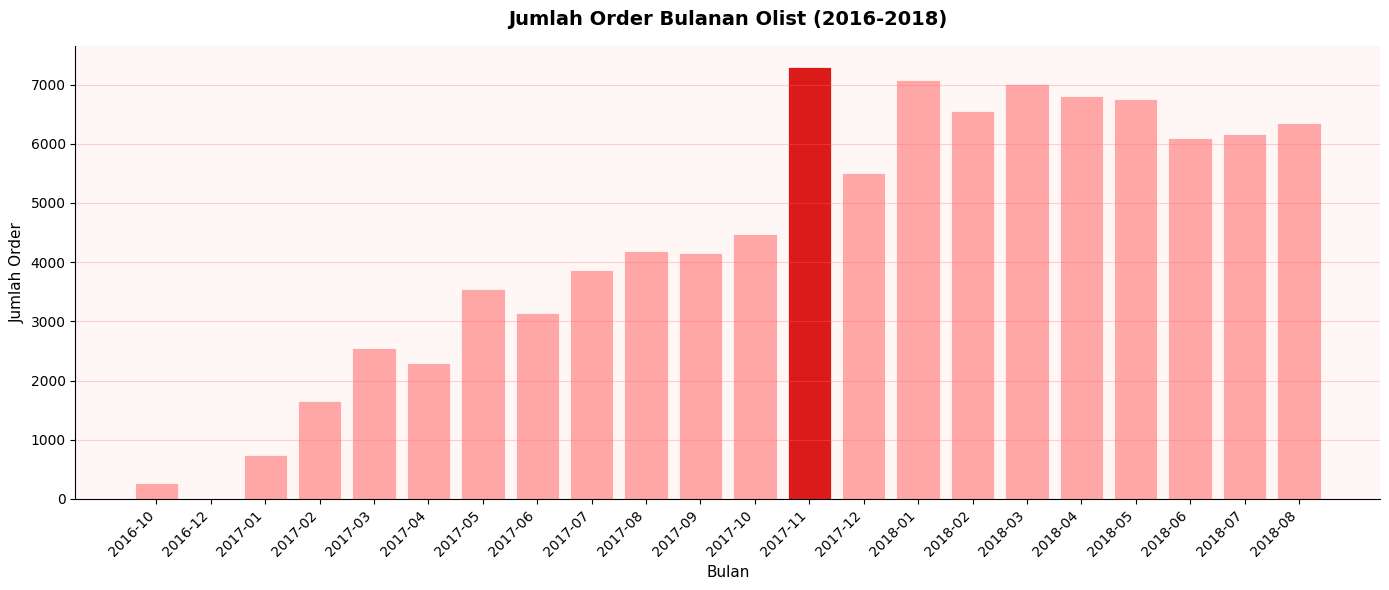

In [84]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(COLOR_CREAM)

colors_bar = [COLOR_PRIMARY if x == monthly_orders['total_orders'].max()
              else COLOR_PASTEL for x in monthly_orders['total_orders']]

bars = ax.bar(range(len(monthly_orders)),
              monthly_orders['total_orders'],
              color=colors_bar, edgecolor='white', linewidth=0.5)

ax.set_title('Jumlah Order Bulanan Olist (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Order', fontsize=11)
ax.set_xticks(range(len(monthly_orders)))
ax.set_xticklabels(monthly_orders['year_month'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, color=COLOR_SECONDARY)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/order_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan Bisnis 2: Segmentasi Pelanggan RFM

In [85]:
Grafik Distribusi Segmen RFM

SyntaxError: invalid syntax (1414689785.py, line 1)

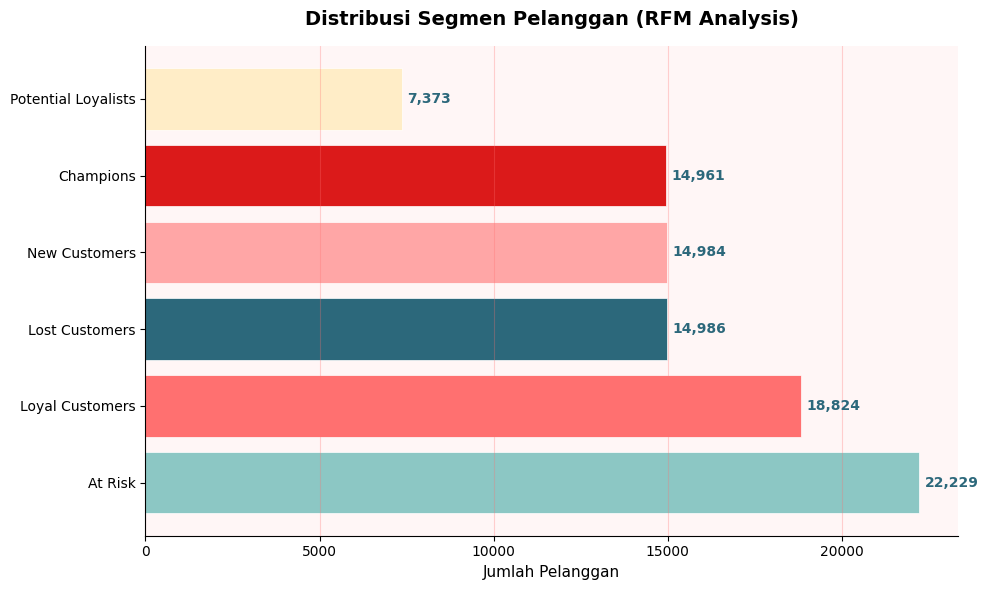

In [ ]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
colors_seg = [SEGMENT_COLORS[s] for s in segment_counts['Segment']]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(COLOR_CREAM)

bars = ax.barh(segment_counts['Segment'],
               segment_counts['Count'],
               color=colors_seg, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, segment_counts['Count']):
    ax.text(bar.get_width() + 150,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10,
            color=COLOR_TEAL_DARK, fontweight='bold')

ax.set_title('Distribusi Segmen Pelanggan (RFM Analysis)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Pelanggan', fontsize=11)
ax.grid(axis='x', alpha=0.3, color=COLOR_SECONDARY)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/rfm_segment.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik Rata-rata Monetary per Segmen

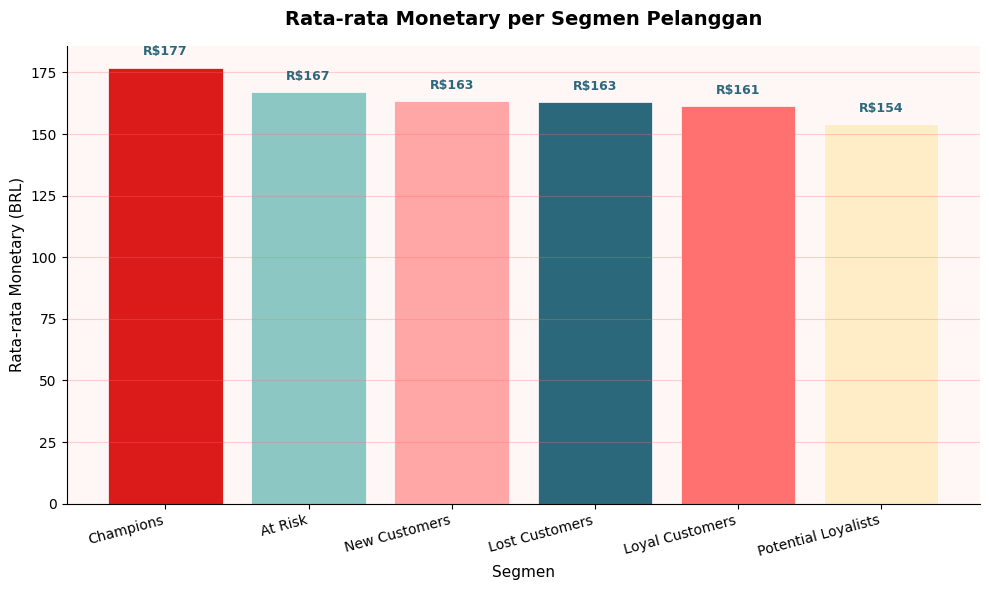

In [ ]:
rfm_summary = rfm.groupby('Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('customer_unique_id', 'count')
).reset_index().sort_values('Avg_Monetary', ascending=False)

colors_mon = [SEGMENT_COLORS[s] for s in rfm_summary['Segment']]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(COLOR_CREAM)

bars = ax.bar(range(len(rfm_summary)),
              rfm_summary['Avg_Monetary'],
              color=colors_mon, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, rfm_summary['Avg_Monetary']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'R${val:,.0f}', ha='center', fontsize=9,
            color=COLOR_TEAL_DARK, fontweight='bold')

ax.set_title('Rata-rata Monetary per Segmen Pelanggan',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Segmen', fontsize=11)
ax.set_ylabel('Rata-rata Monetary (BRL)', fontsize=11)
ax.set_xticks(range(len(rfm_summary)))
ax.set_xticklabels(rfm_summary['Segment'], rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3, color=COLOR_SECONDARY)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/rfm_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Lanjutan

### 1. Geospatial Analysis
Analisis distribusi pelanggan berdasarkan lokasi geografis di Brazil menggunakan data geolocation.

In [ ]:
# Merge customers dengan geolocation berdasarkan zip code
customers_geo = customers.merge(
    geolocation[['geolocation_zip_code_prefix', 
                 'geolocation_lat', 
                 'geolocation_lng',
                 'geolocation_state']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).drop_duplicates(subset='customer_id')

# Hitung jumlah pelanggan per state
customers_per_state = customers_geo.groupby('geolocation_state')['customer_id'].count().reset_index()
customers_per_state.columns = ['state', 'total_customers']
customers_per_state = customers_per_state.sort_values('total_customers', ascending=False)

print("TOP 10 STATE DENGAN PELANGGAN TERBANYAK")
print(customers_per_state.head(10))

=== TOP 10 STATE DENGAN PELANGGAN TERBANYAK ===
   state  total_customers
25    SP            41731
18    RJ            12839
10    MG            11624
22    RS             5462
17    PR             5034
23    SC             3637
4     BA             3371
7     ES             2027
8     GO             2011
6     DF             1969


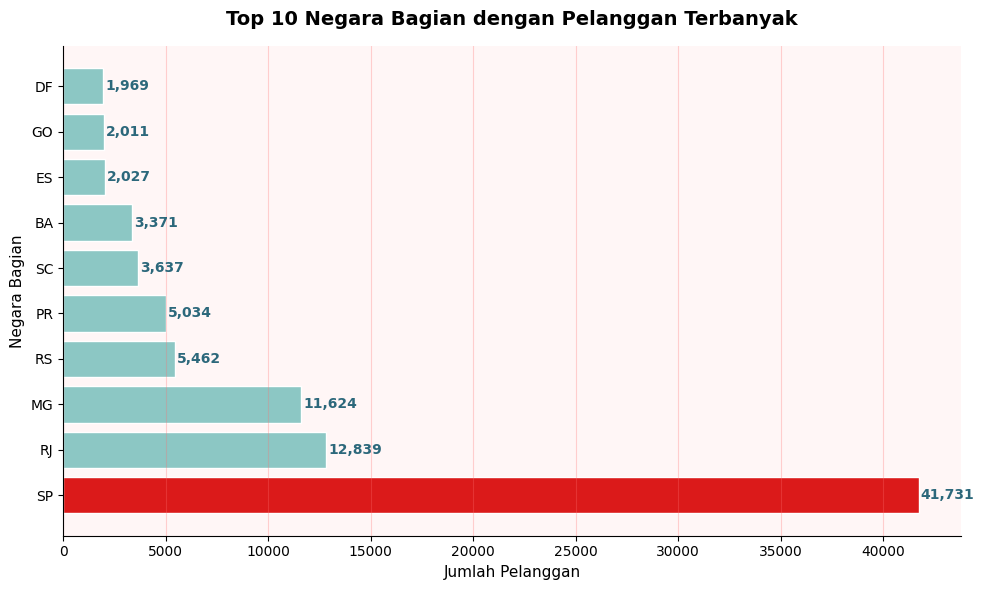

In [ ]:
top10_states = customers_per_state.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(COLOR_CREAM)

colors_geo = [COLOR_PRIMARY if i == 0 else COLOR_TEAL 
              for i in range(len(top10_states))]

bars = ax.barh(top10_states['state'], 
               top10_states['customer_count'],
               color=colors_geo, edgecolor='white')

for bar, val in zip(bars, top10_states['customer_count']):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10,
            color=COLOR_TEAL_DARK, fontweight='bold')

ax.set_title('Top 10 Negara Bagian dengan Pelanggan Terbanyak',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Pelanggan', fontsize=11)
ax.set_ylabel('Negara Bagian', fontsize=11)
ax.grid(axis='x', alpha=0.3, color=COLOR_SECONDARY)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/geo_state.png', dpi=150, bbox_inches='tight')
plt.show()

Membuat peta interaktif Brazil menggunakan library folium. Setiap titik di peta mewakili koordinat pelanggan. Warna merah untuk state dengan pelanggan terbanyak (SP), teal untuk yang lainnya. 

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Buat peta terpusat di Brazil
m = folium.Map(location=[-15.77972, -47.92972], 
               zoom_start=4,
               tiles='CartoDB positron')

# Ambil sample 2000 titik supaya peta tidak berat
sample_geo = customers_geo.dropna(subset=['lat', 'lng']).sample(2000, random_state=42)

# Tambah marker cluster
marker_cluster = MarkerCluster().add_to(m)

for _, row in sample_geo.iterrows():
    color = '#DB1A1A' if row['state'] == 'SP' else '#2C687B'
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"State: {row['state']}"
    ).add_to(marker_cluster)

# Simpan peta
m.save('dashboard/geo_map.html')
print("Peta berhasil disimpan di dashboard/geo_map.html")
print(f"Total titik: {len(sample_geo)}")

Peta berhasil disimpan di dashboard/geo_map.html
Total titik: 2000


### 2. Clustering
Mengelompokkan pelanggan ke dalam kategori berdasarkan nilai Monetary menggunakan teknik binning (manual grouping).
Tujuannya untuk memahami distribusi spending pelanggan.

In [ ]:
# Tentukan batas cluster berdasarkan nilai Monetary
bins = [0, 100, 300, 600, float('inf')]
labels = ['Low Spender', 'Medium Spender', 'High Spender', 'Premium Spender']

rfm['Spending_Cluster'] = pd.cut(rfm['Monetary'], 
                                  bins=bins, 
                                  labels=labels)

cluster_counts = rfm['Spending_Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Count']
cluster_counts = cluster_counts.sort_values('Cluster')

print("=== DISTRIBUSI SPENDING CLUSTER ===")
print(cluster_counts)
print(f"\nTotal pelanggan: {cluster_counts['Count'].sum():,}")

=== DISTRIBUSI SPENDING CLUSTER ===
           Cluster  Count
0      Low Spender  43249
1   Medium Spender  39771
2     High Spender   7125
3  Premium Spender   3212

Total pelanggan: 93,357


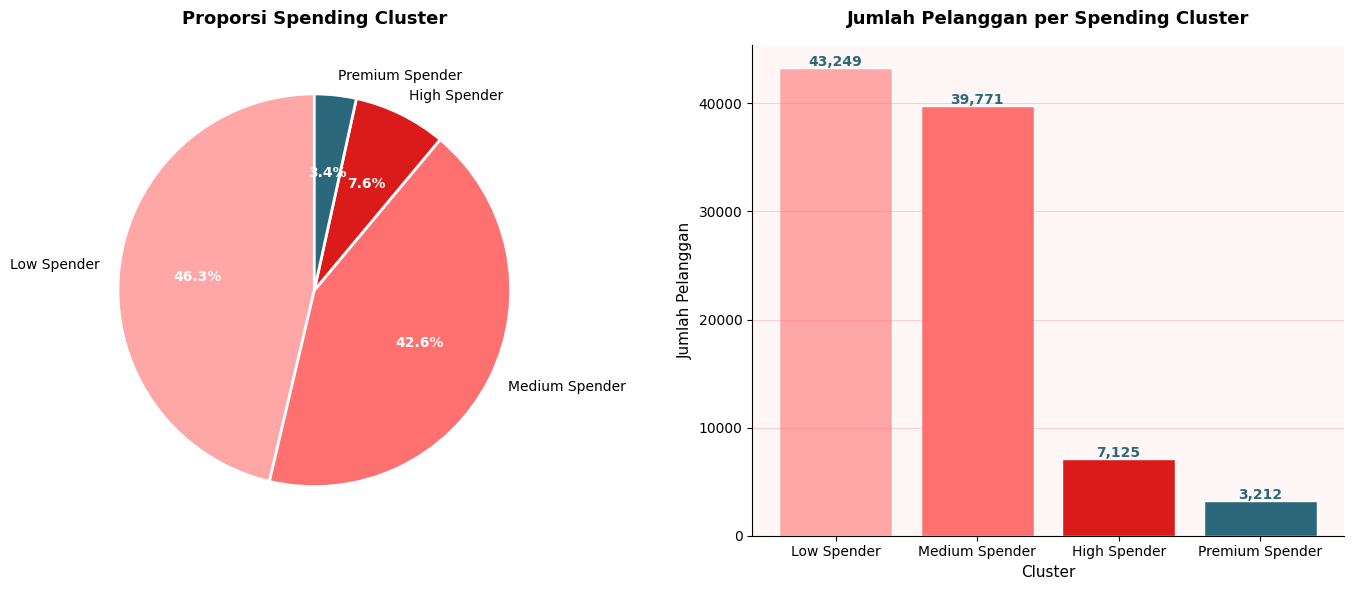

In [ ]:
cluster_colors = [COLOR_PASTEL, COLOR_SECONDARY, 
                  COLOR_PRIMARY, COLOR_TEAL_DARK]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Pie chart
wedges, texts, autotexts = ax1.pie(
    cluster_counts['Count'],
    labels=cluster_counts['Cluster'],
    colors=cluster_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_color('white')
    text.set_fontweight('bold')
ax1.set_title('Proporsi Spending Cluster', 
              fontsize=13, fontweight='bold', pad=15)

# Bar chart
ax2.set_facecolor(COLOR_CREAM)
bars = ax2.bar(cluster_counts['Cluster'],
               cluster_counts['Count'],
               color=cluster_colors, edgecolor='white')

for bar, val in zip(bars, cluster_counts['Count']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10,
             color=COLOR_TEAL_DARK, fontweight='bold')

ax2.set_title('Jumlah Pelanggan per Spending Cluster',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Cluster', fontsize=11)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax2.grid(axis='y', alpha=0.3, color=COLOR_SECONDARY)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion & Recommendation

### Kesimpulan Pertanyaan Bisnis 1
Bagaimana tren total revenue bulanan Olist selama periode 2016–2018?

**Kesimpulan:**

1. Revenue Olist menunjukkan tren **pertumbuhan yang konsisten** dari Oktober 2016 hingga November 2017, dengan lonjakan signifikan pada bulan November 2017 
yang mencapai R$1.153.528 — kemungkinan besar dipicu oleh event **Black Friday / Harbolnas**.

2. Setelah November 2017, revenue tetap tinggi di kisaran R$966.000 - R$1.132.000 per bulan sepanjang 2018, menandakan bisnis sudah mencapai **tahap stabil**.

3. Jumlah order tertinggi juga terjadi di **November 2017** dengan 7.289 order, selaras dengan lonjakan revenue.

### Kesimpulan Pertanyaan Bisnis 2
Bagaimana segmentasi pelanggan berdasarkan RFM Analysis?

**Kesimpulan:**

1. Segmen **At Risk** adalah yang paling dominan dengan 22.229 pelanggan (23.8%), 
artinya hampir seperempat pelanggan Olist dulunya aktif namun sudah lama 
tidak melakukan pembelian — ini adalah **alarm serius** bagi bisnis.

2. Segmen **Champions** hanya berjumlah 14.961 pelanggan (16%), 
padahal mereka adalah pelanggan paling berharga dengan rata-rata 
monetary tertinggi. Perlu strategi khusus untuk **mempertahankan** segmen ini.

3. Mayoritas pelanggan (>90%) hanya melakukan **1 kali transaksi** 
(Frequency = 1), menunjukkan tingkat **repeat purchase yang sangat rendah**.

### Kesimpulan Geospatial & Clustering

**Kesimpulan:**

1. Pelanggan Olist terkonsentrasi di negara bagian **SP (São Paulo)** 
dengan jumlah terbanyak, diikuti RJ (Rio de Janeiro) dan MG (Minas Gerais). 
Strategi pemasaran sebaiknya diprioritaskan di ketiga wilayah ini.

2. Dari clustering spending, mayoritas pelanggan masuk kategori 
**Low Spender** (belanja < R$100), menunjukkan peluang besar untuk 
meningkatkan **average order value** melalui strategi upselling dan bundling.

## Tambahan Fitur

In [88]:
# Merge products dengan terjemahan kategori
products_translated = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)
products_translated['product_category_name_english'] = \
    products_translated['product_category_name_english'].fillna('others')

# Merge order_items dengan products
items_with_category = order_items.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Merge ke main_data
main_data_final = main_data.merge(
    items_with_category[['order_id', 'product_category_name_english']],
    on='order_id',
    how='left'
)

# Simpan ulang
main_data_final.to_csv('dashboard/main_data.csv', index=False)

print(f"\nTop 10 kategori:")
print(main_data_final['product_category_name_english'].value_counts().head(10))
print(f"\nTotal kategori unik: {main_data_final['product_category_name_english'].nunique()}")


Top 10 kategori:
product_category_name_english
bed_bath_table           11650
health_beauty             9759
sports_leisure            8733
furniture_decor           8557
computers_accessories     7898
housewares                7172
watches_gifts             6065
telephony                 4603
garden_tools              4464
auto                      4284
Name: count, dtype: int64

Total kategori unik: 72


In [ ]:
# customer_city sudah ada di main_data, langsung simpan ulang saja
main_data.to_csv('dashboard/main_data.csv', index=False)

print(f"\nContoh kota:")
print(main_data['customer_city'].value_counts().head(10))
print(f"\nTotal kota unik: {main_data['customer_city'].nunique()}")

main_data berhasil disimpan!

Contoh kota:
customer_city
sao paulo                15697
rio de janeiro            6917
belo horizonte            2792
brasilia                  2131
curitiba                  1544
campinas                  1477
porto alegre              1380
salvador                  1290
guarulhos                 1203
sao bernardo do campo      952
Name: count, dtype: int64

Total kota unik: 4085


In [ ]:
# Gabungkan semua data yang dibutuhkan dashboard
main_data = order_revenue.merge(customers, on='customer_id', how='left')

# Simpan ke folder dashboard
main_data.to_csv('dashboard/main_data.csv', index=False)

# Simpan juga rfm
rfm.to_csv('dashboard/rfm_data.csv', index=False)

# Simpan customers_geo
customers_geo.to_csv('dashboard/customers_geo.csv', index=False)

print("Semua data berhasil disimpan!")
print(f"main_data     : {main_data.shape}")
print(f"rfm_data      : {rfm.shape}")
print(f"customers_geo : {customers_geo.shape}")

Semua data berhasil disimpan!
main_data     : (100756, 17)
rfm_data      : (93357, 10)
customers_geo : (99441, 9)


In [89]:
# Merge review score ke main_data
main_data_final = pd.read_csv('dashboard/main_data.csv',
                               parse_dates=['order_purchase_timestamp'])

# Tambah review score
reviews_clean = order_reviews[['order_id', 'review_score']].drop_duplicates('order_id')
main_data_final = main_data_final.merge(reviews_clean, on='order_id', how='left')

# Tambah waktu pengiriman
orders_delivery = orders[['order_id', 
                           'order_delivered_customer_date',
                           'order_estimated_delivery_date']].copy()

orders_delivery['order_delivered_customer_date'] = pd.to_datetime(
    orders_delivery['order_delivered_customer_date'])
orders_delivery['order_estimated_delivery_date'] = pd.to_datetime(
    orders_delivery['order_estimated_delivery_date'])

# Hitung selisih hari (negatif = lebih cepat, positif = terlambat)
orders_delivery['delivery_diff_days'] = (
    orders_delivery['order_delivered_customer_date'] - 
    orders_delivery['order_estimated_delivery_date']
).dt.days

# Hitung aktual lama pengiriman dari tanggal pembelian
main_data_final['order_purchase_timestamp'] = pd.to_datetime(
    main_data_final['order_purchase_timestamp'])
orders_delivery2 = orders[['order_id',
                            'order_purchase_timestamp',
                            'order_delivered_customer_date']].copy()
orders_delivery2['order_purchase_timestamp'] = pd.to_datetime(
    orders_delivery2['order_purchase_timestamp'])
orders_delivery2['order_delivered_customer_date'] = pd.to_datetime(
    orders_delivery2['order_delivered_customer_date'])
orders_delivery2['actual_delivery_days'] = (
    orders_delivery2['order_delivered_customer_date'] - 
    orders_delivery2['order_purchase_timestamp']
).dt.days

orders_delivery = orders_delivery.merge(
    orders_delivery2[['order_id', 'actual_delivery_days']],
    on='order_id', how='left'
)

main_data_final = main_data_final.merge(
    orders_delivery[['order_id', 'delivery_diff_days', 'actual_delivery_days']],
    on='order_id', how='left'
)

# Simpan ulang
main_data_final.to_csv('dashboard/main_data.csv', index=False)

print("Data berhasil diupdate!")
print(f"\nKolom baru: review_score, delivery_diff_days, actual_delivery_days")
print(f"\nRata-rata review score: {main_data_final['review_score'].mean():.2f}")
print(f"Rata-rata hari pengiriman aktual: {main_data_final['actual_delivery_days'].mean():.1f} hari")
print(f"Order terlambat: {(main_data_final['delivery_diff_days'] > 0).sum():,}")
print(f"Order tepat waktu/lebih cepat: {(main_data_final['delivery_diff_days'] <= 0).sum():,}")

Data berhasil diupdate!

Kolom baru: review_score, delivery_diff_days, actual_delivery_days

Rata-rata review score: 4.08
Rata-rata hari pengiriman aktual: 12.0 hari
Order terlambat: 7,526
Order tepat waktu/lebih cepat: 107,501


In [90]:
# Mapping nama kategori ke format lebih rapi
category_mapping = {
    'bed_bath_table': 'Bed Bath Table',
    'health_beauty': 'Health Beauty',
    'sports_leisure': 'Sports Leisure',
    'furniture_decor': 'Furniture Decor',
    'computers_accessories': 'Computers Accessories',
    'housewares': 'Housewares',
    'watches_gifts': 'Watches Gifts',
    'telephony': 'Telephony',
    'garden_tools': 'Garden Tools',
    'auto': 'Auto',
    'toys': 'Toys',
    'cool_stuff': 'Cool Stuff',
    'perfumery': 'Perfumery',
    'baby': 'Baby',
    'electronics': 'Electronics',
    'stationery': 'Stationery',
    'fashion_bags_accessories': 'Fashion Bags Accessories',
    'pet_shop': 'Pet Shop',
    'office_furniture': 'Office Furniture',
    'books_general_interest': 'Books General Interest',
    'construction_tools_lights': 'Construction Tools Lights',
    'food_drink': 'Food Drink',
    'musical_instruments': 'Musical Instruments',
    'consoles_games': 'Consoles Games',
    'air_conditioning': 'Air Conditioning',
    'fashion_shoes': 'Fashion Shoes',
    'computers': 'Computers',
    'small_appliances': 'Small Appliances',
    'furniture_living_room': 'Furniture Living Room',
    'luggage_accessories': 'Luggage Accessories',
    'costumes_accessories': 'Costumes Accessories',
    'kitchen_dining_laundry_garden_furniture': 'Kitchen Dining Laundry Garden Furniture',
    'home_appliances': 'Home Appliances',
    'fixed_telephony': 'Fixed Telephony',
    'party_supplies': 'Party Supplies',
    'home_comfort': 'Home Comfort',
    'signaling_and_security': 'Signaling And Security',
    'agro_industry_and_commerce': 'Agro Industry And Commerce',
    'fashion_male_clothing': 'Fashion Male Clothing',
    'drinks': 'Drinks',
    'construction_tools_construction': 'Construction Tools Construction',
    'books_imported': 'Books Imported',
    'food': 'Food',
    'art': 'Art',
    'arts_and_craftmanship': 'Arts And Craftmanship',
    'home_appliances_2': 'Home Appliances 2',
    'tablets_printing_image': 'Tablets Printing Image',
    'furniture_mattress_and_upholstery': 'Furniture Mattress And Upholstery',
    'fashion_female_clothing': 'Fashion Female Clothing',
    'fashion_sport': 'Fashion Sport',
    'construction_tools_tools': 'Construction Tools',
    'flowers': 'Flowers',
    'market_place': 'Market Place',
    'diapers_and_hygiene': 'Diapers And Hygiene',
    'dvds_blu_ray': 'DVDs Blu Ray',
    'la_cuisine': 'La Cuisine',
    'christmas_supplies': 'Christmas Supplies',
    'audio': 'Audio',
    'fashion_underwear_beach': 'Fashion Underwear Beach',
    'home_confort': 'Home Comfort',
    'music': 'Music',
    'books_technical': 'Books Technical',
    'industry_commerce_and_business': 'Industry Commerce And Business',
    'cds_dvds_musicals': 'CDs DVDs Musicals',
    'others': 'Others',
    'furniture_bedroom': 'Furniture Bedroom',
    'cine_photo': 'Cine Photo',
    'security_and_services': 'Security And Services',
    'pc_gamer': 'PC Gamer',
    'portateis_casa_forno_e_cafe': 'Portable Home Oven Coffee',
    'seguros_e_servicos': 'Insurance And Services'
}

# Reload main_data
main_data_final = pd.read_csv('dashboard/main_data.csv',
                               parse_dates=['order_purchase_timestamp'])

# Terapkan mapping
main_data_final['product_category_name_english'] = (
    main_data_final['product_category_name_english']
    .map(category_mapping)
    .fillna(main_data_final['product_category_name_english']
            .str.replace('_', ' ').str.title())
)

# Simpan ulang
main_data_final.to_csv('dashboard/main_data.csv', index=False)

print("\nContoh kategori setelah update:")
print(main_data_final['product_category_name_english'].value_counts().head(10))


Contoh kategori setelah update:
product_category_name_english
Bed Bath Table           11650
Health Beauty             9759
Sports Leisure            8733
Furniture Decor           8557
Computers Accessories     7898
Housewares                7172
Watches Gifts             6065
Telephony                 4603
Garden Tools              4464
Auto                      4284
Name: count, dtype: int64


In [91]:
import requests
import json
import os

# Download GeoJSON Brazil provinces
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
response = requests.get(url)

if response.status_code == 200:
    with open('dashboard/brazil_states.geojson', 'w') as f:
        f.write(response.text)
    print("GeoJSON berhasil didownload!")
    
    # Cek isi
    geo_data = json.loads(response.text)
    print(f"Jumlah provinsi: {len(geo_data['features'])}")
    print(f"Contoh property: {geo_data['features'][0]['properties']}")
else:
    print(f"Gagal download: {response.status_code}")

GeoJSON berhasil didownload!
Jumlah provinsi: 27
Contoh property: {'id': 1, 'name': 'Acre', 'sigla': 'AC', 'regiao_id': '3', 'codigo_ibg': '12', 'cartodb_id': 1, 'created_at': '2015-02-09T16:46:01Z', 'updated_at': '2015-02-09T16:46:01Z'}
